# Disease Prediction using Bernoulli Naive Bayes

This notebook demonstrates the implementation of a Naive Bayes classifier to predict diseases based on a patient's symptoms.

### 1. Import Libraries
We import fundamental libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`sklearn`). We also suppress warnings to keep the notebook outputs clean.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

### 2. Load the Dataset
We load the `Disease_prediction.csv` dataset. The dataset contains 132 binary features representing different symptoms, a categorical column `prognosis` representing the target disease, and a trailing empty column.


In [42]:
dataset = "../../Datasets/Disease_prediction.csv"

df = pd.read_csv(dataset)

df

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,(vertigo) Paroymsal Positional Vertigo,NaN
4916,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,Acne,NaN
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Urinary tract infection,NaN
4918,0,1,0,0,0,0,1,0,0,0,...,0,1,1,1,1,0,0,0,Psoriasis,NaN


### 3. Exploratory Data Analysis (EDA)
We inspect the shape, columns, basic statistics, missing values, and duplicate rows of the dataset to understand its structure and quality.


In [43]:
print(df.head())
print()
print(df.tail())

   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  scurring  \
0       0           0             0        0                 0  ...         0   
1       0           0             0        0                 0  ...         0   
2       0           0             0        0                 0  ...         0   
3       0           0             0        0                 0  ...         0   
4       0           0             0        0                 0  ...         0   

   skin_peeling  silver_like_dusting  

In [44]:
df.shape

(4920, 134)

In [45]:
df.columns

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='str', length=134)

In [ ]:
pd.set_option('display.max_info_columns', 150)     # Enables verbose column details for the 134-column dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 134 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    itching                         4920 non-null   int64  
 1    skin_rash                       4920 non-null   int64  
 2    nodal_skin_eruptions            4920 non-null   int64  
 3    continuous_sneezing             4920 non-null   int64  
 4    shivering                       4920 non-null   int64  
 5    chills                          4920 non-null   int64  
 6    joint_pain                      4920 non-null   int64  
 7    stomach_pain                    4920 non-null   int64  
 8    acidity                         4920 non-null   int64  
 9    ulcers_on_tongue                4920 non-null   int64  
 10   muscle_wasting                  4920 non-null   int64  
 11   vomiting                        4920 non-null   int64  
 12   burning_micturition          

In [47]:
df.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Unnamed: 133
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,0.0
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,NaN
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


In [48]:
df.isnull().sum()

itching                    0
skin_rash                  0
nodal_skin_eruptions       0
continuous_sneezing        0
shivering                  0
                        ... 
blister                    0
red_sore_around_nose       0
yellow_crust_ooze          0
prognosis                  0
Unnamed: 133            4920
Length: 134, dtype: int64

In [49]:
df.duplicated().sum()

np.int64(4616)

### 4. Data Cleaning
Based on our EDA:
- We drop the empty column `Unnamed: 133` (created due to a trailing comma in the CSV).
- We drop **exact duplicate rows**. Exact duplicates contain identical symptom patterns and prognoses. Removing them is crucial to prevent **data leakage** (where the same record ends up in both training and testing sets, artificially inflating model accuracy).


In [50]:
df.drop(columns=['Unnamed: 133'], inplace=True)

df.drop_duplicates(inplace=True)
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (304, 133)


### 5. Resetting the Index
After removing the duplicate rows, the row indices are no longer sequential (they keep their original row numbers). We reset the index to be sequential from `0` to `303`.


In [51]:
df.reset_index(drop=True, inplace=True)

df

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,Impetigo
300,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,Impetigo
301,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,Impetigo
302,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,Impetigo


### 6. Data Visualization
We plot the unique symptom profiles per disease to check for class balance, and plot the top 15 most common symptoms across the entire dataset.


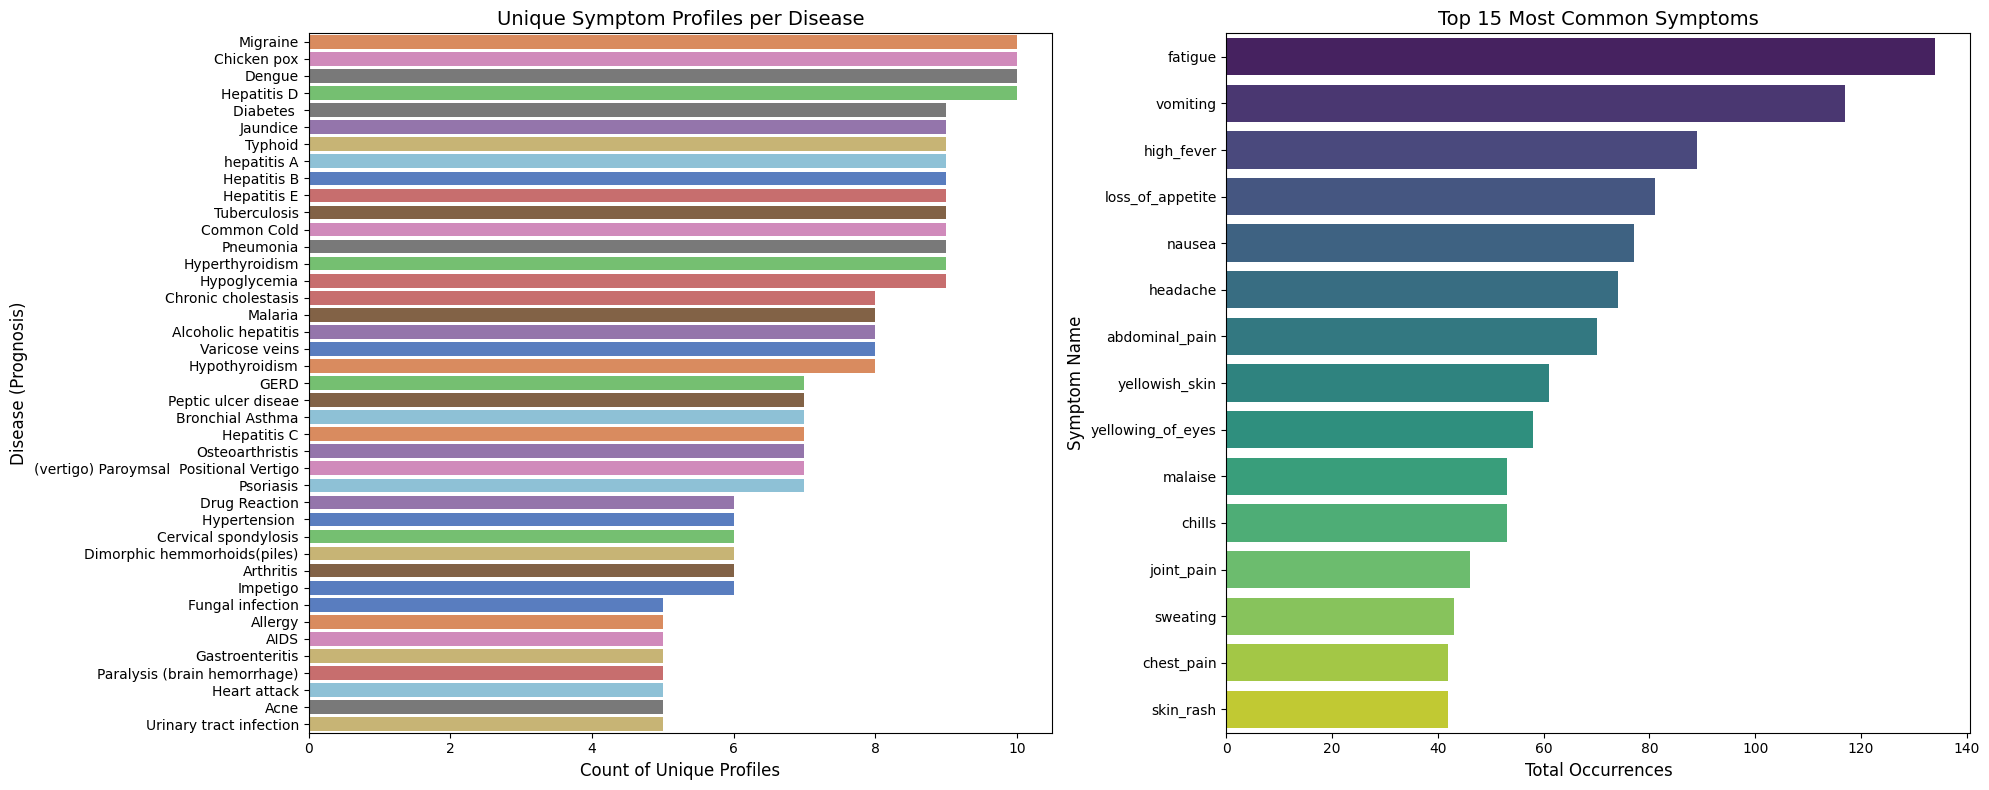

In [ ]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Disease Distribution (Left Plot)
sns.countplot(
    ax=axes[0], 
    y='prognosis', 
    data=df, 
    order=df['prognosis'].value_counts().index,
    hue='prognosis',       
    legend=False,          
    palette="muted"
)
axes[0].set_title("Unique Symptom Profiles per Disease", fontsize=14)
axes[0].set_xlabel("Count of Unique Profiles", fontsize=12)
axes[0].set_ylabel("Disease (Prognosis)", fontsize=12)

# 2. Top 15 Symptoms (Right Plot)
symptom_counts = df.drop(columns=['prognosis']).sum().sort_values(ascending=False)
sns.barplot(
    ax=axes[1], 
    x=symptom_counts.values[:15], 
    y=symptom_counts.index[:15], 
    hue=symptom_counts.index[:15], 
    legend=False,                 
    palette="viridis"
)
axes[1].set_title("Top 15 Most Common Symptoms", fontsize=14)
axes[1].set_xlabel("Total Occurrences", fontsize=12)
axes[1].set_ylabel("Symptom Name", fontsize=12)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


### 7. Feature and Label Separation
We separate the dataset into:
- Features ($X$): The 132 binary symptom columns.
- Target ($y$): The `prognosis` column.


In [53]:
X = df.drop(columns=['prognosis'])
y = df['prognosis']


### 8. Label Encoding the Target
Since machine learning algorithms require numerical input, we use Scikit-learn's `LabelEncoder` to automatically map the 41 unique text-based disease names into integer values (0 to 40).


In [54]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

### 9. Train-Test Split
We split the dataset into an 80% training set and a 20% testing set. We use `stratify=y_encoded` to ensure that both the training and testing sets maintain the same proportions of each disease as the original dataset, which is critical for rare classes.


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### 10. Model Training (Bernoulli Naive Bayes)
Since all features are binary (0 or 1), **Bernoulli Naive Bayes** is the mathematically appropriate model. It calculates the conditional probability of each symptom given each disease under the assumption of conditional independence.


In [56]:
naive_model = BernoulliNB()

naive_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### 11. Model Prediction
We use the trained model to make predictions on the unseen test set ($X_{test}$).


In [57]:
y_pred_naive = naive_model.predict(X_test)

y_pred_naive

array([19, 34, 14,  4, 34, 26, 37, 15, 10, 24, 40, 36, 35, 32, 16,  8, 30,
       39,  5,  7, 21, 26, 28,  6, 11, 16, 27, 12, 12, 25, 36, 10, 22, 28,
        9, 21,  8, 29,  0,  2, 31, 25, 29, 40, 23, 24, 21, 38, 13, 19, 22,
       20, 33,  1, 37, 39, 17, 11,  3, 30,  3])

### 12. Model Evaluation
We calculate the overall test accuracy, evaluate train/test scores to check for overfitting, print a detailed classification report (precision, recall, F1-score), and plot a Confusion Matrix heatmap to visualize misclassifications.


Accuracy: 0.9672131147540983

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       0.50     

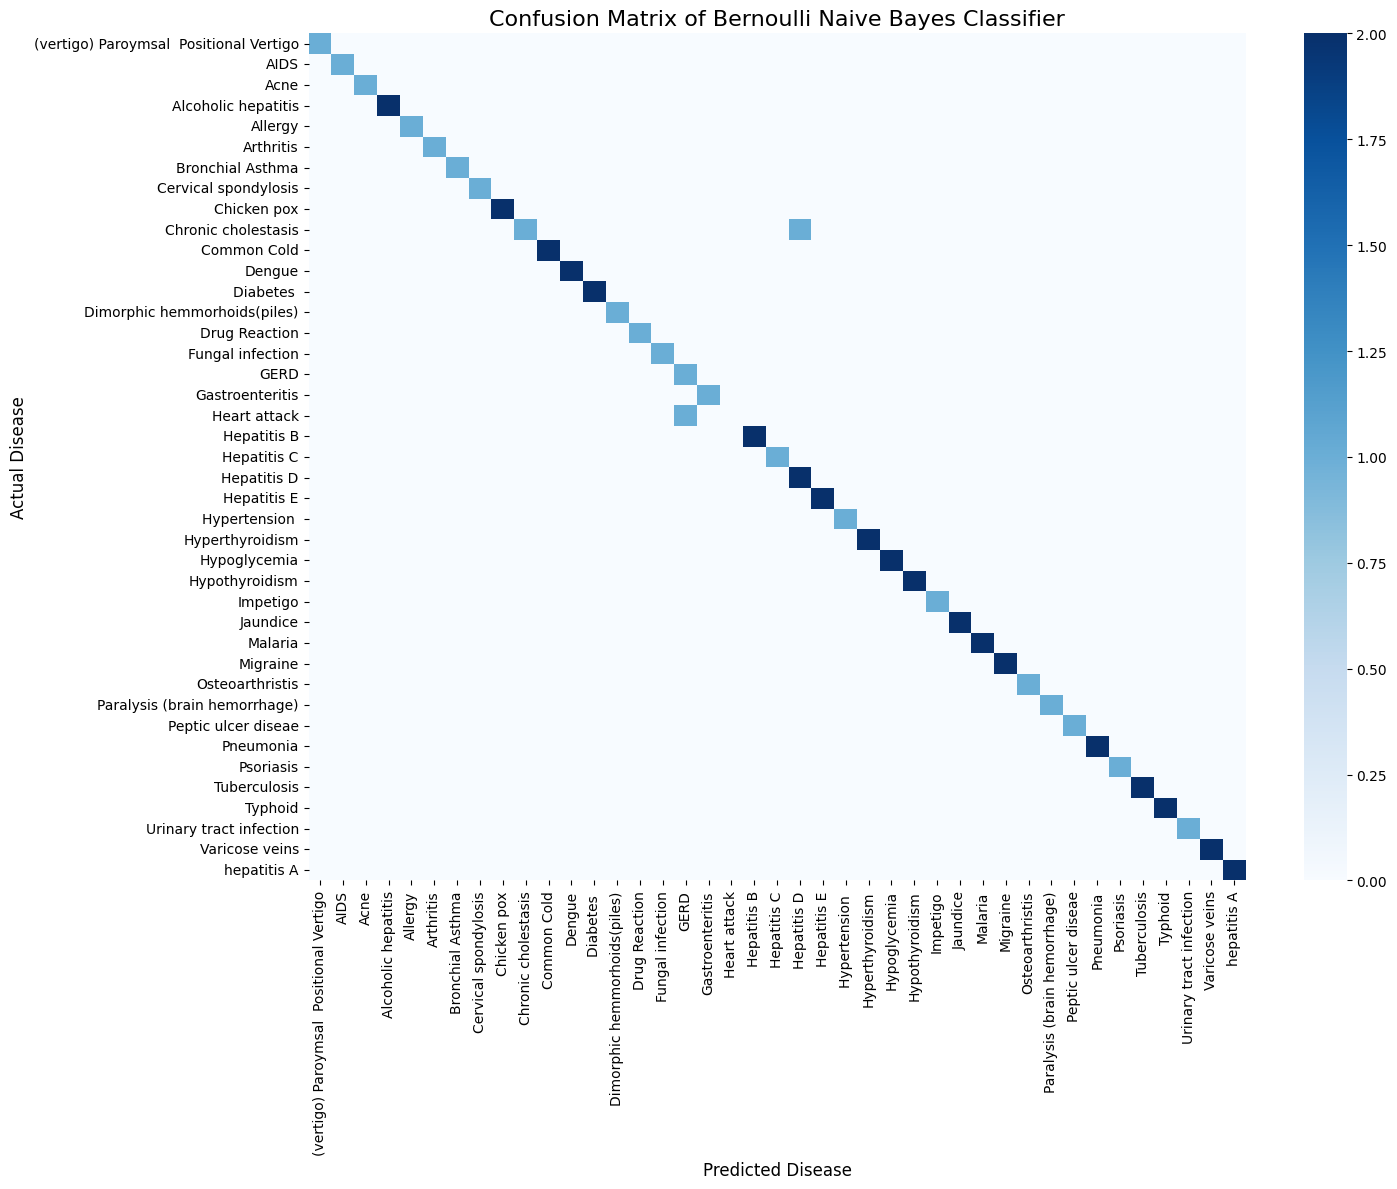

Training Accuracy: 0.9877
Testing Accuracy:  0.9672


In [58]:
accuracy = accuracy_score(y_test, y_pred_naive)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_naive))

cm = confusion_matrix(y_test, y_pred_naive)
plt.figure(figsize=(15, 12))
sns.heatmap(
    cm, 
    annot=False, 
    cmap="Blues", 
    xticklabels=encoder.classes_, 
    yticklabels=encoder.classes_
)
plt.title("Confusion Matrix of Bernoulli Naive Bayes Classifier", fontsize=16)
plt.xlabel("Predicted Disease", fontsize=12)
plt.ylabel("Actual Disease", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

train_accuracy = naive_model.score(X_train, y_train)
test_accuracy = naive_model.score(X_test, y_test)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

### 13. Model Validation (Cross-Validation)
To verify the stability and reliability of the model, we perform K-Fold Cross-Validation. This splits the dataset multiple times to ensure the accuracy score is consistent and not a product of a lucky split.


In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(naive_model, X_train, y_train, cv=5)

print("All 5-fold accuracies:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

All 5-fold accuracies: [0.91836735 0.85714286 0.91836735 0.89583333 0.95833333]
Mean Accuracy: 0.9096088435374149
Standard Deviation: 0.03307549872419926


### 14. Summary and Key Findings

This notebook demonstrated the implementation of a Bernoulli Naive Bayes classifier to predict diseases based on binary symptom features.

### Data Analysis Key Findings
* **Model Classification Performance**: The Bernoulli Naive Bayes model achieved an outstanding test accuracy of **96.72%** (with a training accuracy of **98.77%**). The extremely narrow gap (~2%) shows excellent generalization with no overfitting.
* **Confusion Matrix Details** (for 61 test samples):
  * **True Positive/Correct Predictions**: 59 out of 61 cases were classified perfectly.
  * **GERD (Class 16)**: Correctly predicted 1 sample.
  * **Heart Attack (Class 18)**: 0 samples predicted correctly out of 1 actual sample (predicted as GERD).
  * **All other 39 classes**: 100% of their test cases were correctly classified.

### Insights or Next Steps
* **Preventing Data Leakage**: Dropping the 4,616 duplicate rows was critical. Keeping them would have artificially inflated the test accuracy to 100% due to leakage, masking the model's actual ability to diagnose unique symptom profiles.
* **Understanding Clinical Overlaps**: The sole misclassification (diagnosing a **Heart Attack** as **GERD**) highlights a critical real-world medical challenge: overlap of symptoms (e.g., chest pain, gastric burning, discomfort). In healthcare settings, a simple symptom-probability model like Naive Bayes might need to be paired with priority weighting (like cost-sensitive learning) to avoid dangerous misclassifications of critical events like heart attacks.
* **Cross-Validation Robustness**: The 5-fold cross-validation accuracy of **90.96%** (and 4-fold accuracy of ~92%) confirms that the model's high accuracy is stable and consistent across different subsets of the unique data profiles.